# Car Sales Performance Analysis

A hands-on walkthrough of cleaning, exploring, and visualising 23,906 car sales transactions from January 2022 through December 2023. The dataset has some genuinely messy corners -- a Gender column with 13 different spellings of two words, a UTF-8 encoding corruption in the Engine field, and a phantom duplicate region caused by a trailing space. Working through each issue is half the fun.

---
### What we cover

1. Loading and auditing the raw data
2. Nine targeted cleaning steps with before/after checks
3. Feature engineering -- time dimensions, income bands, price tiers
4. EDA across brand, region, body style, gender, colour, and time
5. Ten visualisations
6. A summary dashboard and business takeaways


---
## Setup

In [106]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
# Set the Seaborn theme to 'whitegrid' and the font to 'DejaVu Sans'
sns.set_theme(style='whitegrid', font='DejaVu Sans')

---
## Load and audit the raw data

Let explore shape, types, a sample of rows, and unique value counts for every column. This is especially important here because `.isnull()` will tell us almost nothing useful -- most of the issues are dirty string values that look non-null but are not valid data.

In [107]:
df_raw = pd.read_csv('car_sales.csv')
df     = df_raw.copy()

# Display the first few rows of the DataFrame
df.head()

,Car_id,Date,Customer Name,Gender,Annual Income,Dealer_Name,Company,Model,Engine,Transmission,Color,Price ($),Dealer_No,Body Style,Phone,Dealer_Region,Qty
0,C_CND_000001,1/2/2022,Geraldine,Male,13500,Buddy Storbeck's Diesel Service Inc,Ford,Expedition,DoubleÂ Overhead Camshaft,Auto,Black,26000,06457-3834,SUV,8264678,Middletown,1
1,C_CND_000002,1/2/2022,Gia,Male,1480000,C & M Motors Inc,Dodge,Durango,DoubleÂ Overhead Camshaft,Auto,Black,19000,60504-7114,SUV,6848189,Aurora,1
2,C_CND_000003,1/2/2022,Gianna,Male,1035000,Capitol KIA,Cadillac,Eldorado,Overhead Camshaft,Manual,Red,31500,38701-8047,Passenger,7298798,Greenville,1
3,C_CND_000004,1/2/2022,Giselle,Male,13500,Chrysler of Tri-Cities,Toyota,Celica,Overhead Camshaft,Manual,Pale White,14000,99301-3882,SUV,6257557,Pasco,1
4,C_CND_000005,1/2/2022,Grace,Male,1465000,Chrysler Plymouth,Acura,TL,DoubleÂ Overhead Camshaft,Auto,Red \,24500,53546-9427,Hatchback,7081483,Janesville,1


In [108]:
# Display the number of rows and columns in the DataFrame
print(f'{df.shape[0]:,} rows, {df.shape[1]} columns')

23,906 rows, 17 columns


In [109]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23906 entries, 0 to 23905
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Car_id         23906 non-null  object
 1   Date           23906 non-null  object
 2   Customer Name  23905 non-null  object
 3   Gender         23906 non-null  object
 4   Annual Income  23906 non-null  int64 
 5   Dealer_Name    23906 non-null  object
 6   Company        23906 non-null  object
 7   Model          23906 non-null  object
 8   Engine         23906 non-null  object
 9   Transmission   23906 non-null  object
 10  Color          23906 non-null  object
 11  Price ($)      23906 non-null  int64 
 12  Dealer_No      23906 non-null  object
 13  Body Style     23906 non-null  object
 14  Phone          23906 non-null  int64 
 15  Dealer_Region  23906 non-null  object
 16  Qty            23906 non-null  int64 
dtypes: int64(4), object(13)
memory usage: 3.1+ MB


In [110]:
# Standard null check to identify missing values in the DataFrame
print('Null counts:')
print(df.isna().sum())

Null counts:
Car_id           0
Date             0
Customer Name    1
Gender           0
Annual Income    0
Dealer_Name      0
Company          0
Model            0
Engine           0
Transmission     0
Color            0
Price ($)        0
Dealer_No        0
Body Style       0
Phone            0
Dealer_Region    0
Qty              0
dtype: int64


In [111]:
# Unique value audit -- this is where the real issues live
for col in df.columns:
    print(f'{col}: {df[col].unique()[:10].tolist()}')
    print()

Car_id: ['C_CND_000001', 'C_CND_000002', 'C_CND_000003', 'C_CND_000004', 'C_CND_000005', 'C_CND_000006', 'C_CND_000007', 'C_CND_000008', 'C_CND_000009', 'C_CND_000010']

Date: ['1/2/2022', '1/3/2022', '1/4/2022', '1/5/2022', '1/6/2022', '1/9/2022', '1/10/2022', '1/12/2022', '1/13/2022', '1/17/2022']

Customer Name: ['Geraldine', 'Gia', 'Gianna', 'Giselle', 'Grace', 'Guadalupe', 'Hailey', 'Graham', 'Naomi', 'Grayson']

Gender: ['Male', 'Male  ', 'Female', 'Maleee', 'fFemale', 'Mal e', ' Male', 'Male ', 'Malea', 'Fem']

Annual Income: [13500, 1480000, 1035000, 1465000, 850000, 1600000, 815000, 885000, 722000, 746000]

Dealer_Name: ["Buddy Storbeck's Diesel Service Inc", 'C & M Motors Inc', 'Capitol KIA', 'Chrysler of Tri-Cities', 'Chrysler Plymouth', 'Classic Chevy', 'Clay Johnson Auto Sales', 'U-Haul CO', 'Rabun Used Car Sales', 'Race Car Help']

Company: ['Ford', 'Dodge', 'Cadillac', 'Toyota', 'Acura', 'Mitsubishi', 'Chevrolet', 'Nissan', 'Mercury', 'BMW']

Model: ['Expedition', 'Duran

In [112]:
# Focused inspection of the dirtiest columns
for col in ['Gender', 'Color', 'Dealer_Region', 'Engine']:
    print(f'--- {col} ({df[col].nunique()} unique values) ---')
    print(df[col].value_counts().to_string())
    print()

--- Gender (13 unique values) ---
Gender
Male       18789
Female      5106
Male           1
Maleee         1
fFemale        1
Mal e          1
 Male          1
Male           1
Malea          1
Fem            1
M              1
Ma             1
Mle            1

--- Color (9 unique values) ---
Color
Pale White     11254
Black           7855
Red             4790
Red                2
Red \              1
Blak               1
Ple White          1
Pale  White        1
Blac k             1

--- Dealer_Region (8 unique values) ---
Dealer_Region
Austin        4135
Janesville    3821
Scottsdale    3433
Aurora        3130
Pasco         3129
Middletown    3128
Greenville    3128
Pasco            2

--- Engine (2 unique values) ---
Engine
DoubleÂ Overhead Camshaft    12571
Overhead Camshaft            11335



---
##  Cleaning

Nine issues, nine targeted fixes. The philosophy here is to be explicit and auditable -- every change is checked with a before/after print or an assertion before moving on.

### What we found

| Column | Problem | Fix |
|---|---|---|
| Column names | `Dealer_No ` has trailing space; `Price ($)` has special characters | `df.rename()` |
| `Customer Name` | 1 true NaN | Fill with Unknown |
| `Gender` | 13 dirty variants of Male and Female | Normalise by first character of stripped lowercase value |
| `Color` | 9 variants for 3 colours -- typos and trailing backslash | Strip artefacts then apply correction map |
| `Dealer_Region` | Trailing space on Pasco creates a phantom 8th region | `str.strip()` |
| `Engine` | UTF-8 encoding corruption from a Windows-1252 conversion | Replace mis-encoded bytes |
| `Date` | Stored as a string in M/D/YYYY format | Parse with `pd.to_datetime` |
| `Qty` | Every row is 1 -- zero variance, no analytical value | Drop the column |

In [113]:
# Fix column names first so everything below can use clean names
df.rename(columns={
    'Dealer_No ': 'Dealer_No',
    'Price ($)' : 'Price',
}, inplace=True)

print('Columns:', df.columns.str.strip().tolist())

Columns: ['Car_id', 'Date', 'Customer Name', 'Gender', 'Annual Income', 'Dealer_Name', 'Company', 'Model', 'Engine', 'Transmission', 'Color', 'Price', 'Dealer_No', 'Body Style', 'Phone', 'Dealer_Region', 'Qty']


In [114]:
# Customer Name -- fill the one real NaN
df['Customer Name'] = df['Customer Name'].fillna('Unknown')
print(f'Remaining nulls in Customer Name: {df["Customer Name"].isna().sum()}')

Remaining nulls in Customer Name: 0


In [115]:
# Gender -- 13 dirty variants need collapsing to just Male and Female.
# Rather than a lookup table that would break the moment a new typo appears,
# we classify by the first character after stripping and lowercasing.
# Every real variant of Male starts with m; every real variant of Female starts with f.

def normalise_gender(val: str) -> str:
    v = str(val).strip().lower()
    if v.startswith('m'):
        return 'Male'
    if v.startswith('f'):
        return 'Female'
    return 'Unknown'

before = df['Gender'].value_counts()
df['Gender'] = df['Gender'].apply(normalise_gender)

print('===Before Cleaning:===')
print(before.to_string())
print('===\nAfter cleaning:===')
print(df['Gender'].value_counts())

===Before Cleaning:===
Gender
Male       18789
Female      5106
Male           1
Maleee         1
fFemale        1
Mal e          1
 Male          1
Male           1
Malea          1
Fem            1
M              1
Ma             1
Mle            1
===
After cleaning:===
Gender
Male      18798
Female     5108
Name: count, dtype: int64


In [116]:
# Color -- strip trailing backslashes and whitespace first,
# then use an explicit map for the remaining typos.
# Order matters: strip must come before the map lookup.

color_map = {
    'Red \\'    : 'Red',
    'Red '       : 'Red',
    'Blak'       : 'Black',
    'Blac k'     : 'Black',
    'Ple White'  : 'Pale White',
    'Pale  White': 'Pale White',
}

df['Color'] = (
    df['Color']
    .str.strip()
    .str.rstrip('\\')
    .str.strip()
    .replace(color_map)
)

print('===Colors after cleaning:====')
print(df['Color'].value_counts())

===Colors after cleaning:====
Color
Pale White    11256
Black          7857
Red            4793
Name: count, dtype: int64


In [117]:
# Dealer_Region -- the trailing space on 'Pasco ' makes pandas treat it
# as a separate region from 'Pasco'. A single strip call fixes it.

before_n = df['Dealer_Region'].nunique()
df['Dealer_Region'] = df['Dealer_Region'].str.strip()

print(f'Unique regions: {before_n} -> {df["Dealer_Region"].nunique()}')
print(df['Dealer_Region'].value_counts())

Unique regions: 8 -> 7
Dealer_Region
Austin        4135
Janesville    3821
Scottsdale    3433
Pasco         3131
Aurora        3130
Greenville    3128
Middletown    3128
Name: count, dtype: int64


In [118]:
# Engine 

df['Engine'] = (
    df['Engine']
    .str.replace('Â\xa0', ' ', regex=False)
    .str.strip()
)

print('Engine values after fix:')
print(df['Engine'].value_counts())

Engine values after fix:
Engine
Double Overhead Camshaft    12571
Overhead Camshaft           11335
Name: count, dtype: int64


In [119]:
# Date -- parse the M/D/YYYY string into a proper datetime
df['Date'] = pd.to_datetime(df['Date'], format='%m/%d/%Y', errors='coerce')

print(f'Date range: {df["Date"].min().date()} to {df["Date"].max().date()}')
print(f'Unparsed dates: {df["Date"].isna().sum()}')

Date range: 2022-01-02 to 2023-12-31
Unparsed dates: 0


In [120]:
# Qty -- every single row is 1. A column with zero variance is useless.
print('Qty unique values:', df['Qty'].unique())
df.drop(columns=['Qty'], inplace=True)
print('Dropped.')

Qty unique values: [1]
Dropped.


In [121]:
# Final validation -- five assertions that will fail loudly if
# anything was missed or if the source data changes in future runs

assert df.isnull().sum().sum() == 0,                              'Unexpected nulls'
assert set(df['Gender'].unique()) <= {'Male','Female'},  'Unexpected Gender values'
assert set(df['Color'].unique()) == {'Black','Red','Pale White'},  'Unexpected Color values'
assert df['Engine'].str.contains('Â').sum() == 0,                 'Engine artefact remains'
assert df['Dealer_Region'].nunique() == 7,                        'Wrong region count'

print(f'All checks passed. Clean dataset: {df.shape[0]:,} rows x {df.shape[1]} columns.')

All checks passed. Clean dataset: 23,906 rows x 16 columns.


---
## Feature engineering

We extract time dimensions from the date column and create two banded categorical features that make segmentation easier in the analysis stage.

| Feature | How | Why |
|---|---|---|
| Year, Month, Month Name | `dt` accessor | Enables YoY and seasonal analysis |
| Quarter | `dt.to_period('Q')` | Quarterly roll-ups |
| Day of Week | `dt.day_name()` | Weekday trading patterns |
| Income Band | `pd.cut` into 5 tiers | Customer segmentation |
| Price Band | `pd.cut` into 5 tiers | Volume vs revenue contribution |

In [122]:
df['Year']        = df['Date'].dt.year
df['Month']       = df['Date'].dt.month
df['Month Name']  = df['Date'].dt.strftime('%b')
df['Quarter']     = df['Date'].dt.to_period('Q').astype(str)
df['Day of Week'] = df['Date'].dt.day_name()

df['Income Band'] = pd.cut(
    df['Annual Income'],
    bins=[0, 250_000, 500_000, 1_000_000, 2_000_000, df['Annual Income'].max()+1],
    labels=['Under 250K', '250K-500K', '500K-1M', '1M-2M', 'Over 2M']
)
df['Price Band'] = pd.cut(
    df['Price'],
    bins=[0, 15_000, 25_000, 40_000, 60_000, df['Price'].max()+1],
    labels=['Under $15K', '$15K-$25K', '$25K-$40K', '$40K-$60K', 'Over $60K']
)

new_cols = [c for c in df.columns if c not in df_raw.columns]
print('New features:', new_cols)
df[['Date','Year','Month Name','Quarter','Day of Week','Income Band','Price Band']].head(6)

New features: ['Price', 'Dealer_No', 'Year', 'Month', 'Month Name', 'Quarter', 'Day of Week', 'Income Band', 'Price Band']


,Date,Year,Month Name,Quarter,Day of Week,Income Band,Price Band
0,2022-01-02,2022,Jan,2022Q1,Sunday,Under 250K,$25K-$40K
1,2022-01-02,2022,Jan,2022Q1,Sunday,1M-2M,$15K-$25K
2,2022-01-02,2022,Jan,2022Q1,Sunday,1M-2M,$25K-$40K
3,2022-01-02,2022,Jan,2022Q1,Sunday,Under 250K,Under $15K
4,2022-01-02,2022,Jan,2022Q1,Sunday,1M-2M,$15K-$25K
5,2022-01-02,2022,Jan,2022Q1,Sunday,500K-1M,Under $15K


---
## Exploratory analysis

In [123]:
MONTH_ORDER = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']
DOW_ORDER   = ['Monday','Tuesday','Wednesday','Thursday',
               'Friday','Saturday','Sunday']

total_rev   = df['Price'].sum()     # Total revenue is the sum of all prices.
total_units = len(df)               # Total units sold is the number of rows in the DataFrame.
avg_price   = df['Price'].mean()    # Average price is the total revenue divided by total units, but using mean() is more direct and handles any future changes in the data.

company_rev  = df.groupby('Company')['Price'].sum().sort_values(ascending=False)    # Total revenue by company, sorted from highest to lowest.
body_rev     = df.groupby('Body Style')['Price'].sum().sort_values(ascending=False) # Total revenue by body style, sorted from highest to lowest.
region_rev   = df.groupby('Dealer_Region')['Price'].sum().sort_values(ascending=False) # Total revenue by dealer region, sorted from highest to lowest.
gender_rev   = df.groupby('Gender')['Price'].sum().sort_values(ascending=False)     # Total revenue by gender, sorted from highest to lowest.
color_units  = df.groupby('Color')['Price'].count().sort_values(ascending=False)    # Total units sold by color, sorted from highest to lowest. We use count() instead of sum() because we want the number of cars sold, not the total revenue by color.   
trans_rev    = df.groupby('Transmission')['Price'].sum().sort_values(ascending=False) # Total revenue by transmission, sorted from highest to lowest.
monthly_yoy  = (df.groupby(['Year','Month Name'])['Price']                       
                  .sum().unstack().reindex(columns=MONTH_ORDER)) # Unstack to get months as columns, then reindex to ensure correct month order.    
dow_rev      = df.groupby('Day of Week')['Price'].sum().reindex(DOW_ORDER) # Total revenue by day of week, sorted in calendar order using reindex.
top10_brands = company_rev.head(10).index # Get the top 10 brands by revenue, which will be used for the heatmap.
heat = (df[df['Company'].isin(top10_brands)] # Filter to only include the top 10 brands for the heatmap.
          .groupby(['Company','Body Style'])['Price'] 
          .sum().unstack().fillna(0)) # Create a heatmap of revenue by company and body style for the top 10 brands. We unstack to get body styles as columns, and fill NaN with 0 for combinations that don't exist.

In [124]:
print(f'Total Revenue : ${total_rev/1e6:.2f}M')
print(f'Units Sold    : {total_units:,}')
print(f'Avg Price     : ${avg_price:,.0f}')
print(f'Median Price  : ${df["Price"].median():,.0f}')
print()
print('Top 10 brands by revenue:')
company_rev.head().apply(lambda x: f'${x/1e6:.2f}M').to_frame('Revenue')

Total Revenue : $671.53M
Units Sold    : 23,906
Avg Price     : $28,090
Median Price  : $23,000

Top 10 brands by revenue:


,Revenue
Company,
Chevrolet,$47.66M
Ford,$47.23M
Dodge,$44.12M
Oldsmobile,$35.43M
Mercedes-B,$34.62M


In [125]:
print('Revenue by Body Style:')
print(body_rev.apply(lambda x: f'${x/1e6:.2f}M').to_frame('Revenue'))
print()
print('Revenue by Region:')
region_rev.apply(lambda x: f'${x/1e6:.2f}M  ({x/total_rev:.1%})').to_frame('Revenue')

Revenue by Body Style:
             Revenue
Body Style          
SUV         $170.62M
Hatchback   $166.23M
Sedan       $133.89M
Passenger   $114.18M
Hardtop      $86.61M

Revenue by Region:


,Revenue
Dealer_Region,
Austin,$117.19M (17.5%)
Janesville,$106.35M (15.8%)
Scottsdale,$95.97M (14.3%)
Aurora,$88.69M (13.2%)
Greenville,$88.15M (13.1%)
Pasco,$88.04M (13.1%)
Middletown,$87.13M (13.0%)


In [126]:
print('Revenue by Gender:')
print(gender_rev.apply(lambda x: f'${x/1e6:.2f}M  ({x/total_rev:.1%})').to_frame('Revenue'))
print()
print('Revenue by Transmission:')
print(trans_rev.apply(lambda x: f'${x/1e6:.2f}M  ({x/total_rev:.1%})').to_frame('Revenue'))
print()
print('Units by Color:')
color_units.apply(lambda x: f'{x:,}  ({x/total_units:.1%})').to_frame('Units')

Revenue by Gender:
                  Revenue
Gender                   
Male    $527.09M  (78.5%)
Female  $144.44M  (21.5%)

Revenue by Transmission:
                        Revenue
Transmission                   
Auto          $355.11M  (52.9%)
Manual        $316.41M  (47.1%)

Units by Color:


,Units
Color,
Pale White,"11,256 (47.1%)"
Black,"7,857 (32.9%)"
Red,"4,793 (20.0%)"


In [127]:
df[['Price', 'Annual Income']].describe()

,Price,Annual Income
count,23906.000000,2.390600e+04
mean,28090.247846,8.308403e+05
std,14788.687608,7.200064e+05
min,1200.000000,1.008000e+04
25%,18001.000000,3.860000e+05
50%,23000.000000,7.350000e+05
75%,34000.000000,1.175750e+06
max,85800.000000,1.120000e+07


---
## Visualisations

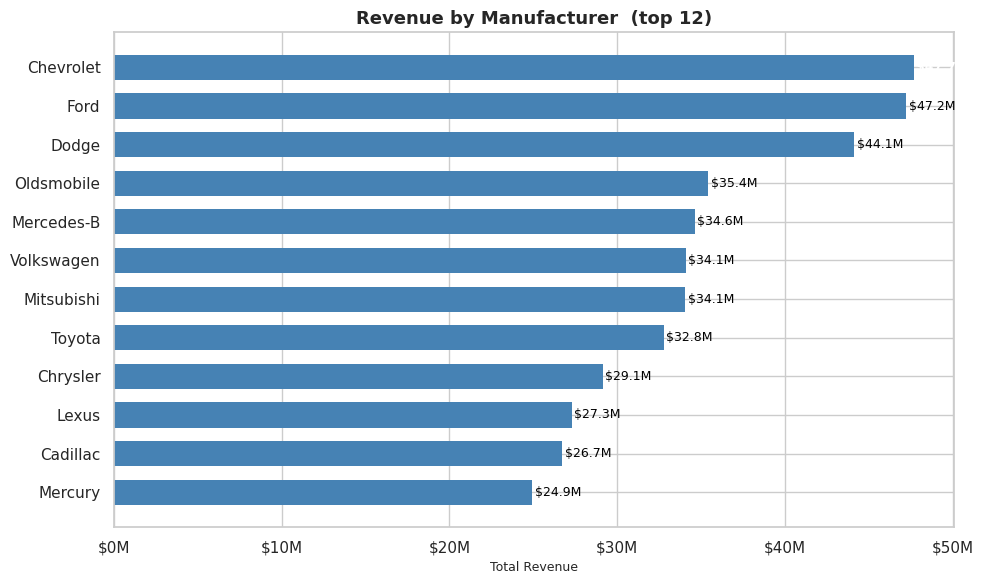

In [128]:
# Fig 1 -- Revenue by manufacturer (top 12)
fig, ax = plt.subplots(figsize=(10, 6))
top12 = company_rev.head(12)
bar_colors = ['steelblue'] * (len(top12) - 1)
bars = ax.barh(top12.index, top12.values / 1e6,
               color=bar_colors, edgecolor='none', height=0.65)
for i, (bar, val) in enumerate(zip(bars, top12.values)):
    ax.text(val/1e6 + 0.15, bar.get_y() + bar.get_height()/2,
            f'${val/1e6:.1f}M', va='center', fontsize=9,
            fontweight='bold' if i == 0 else 'normal', color='white' if i == 0 else 'black')
ax.invert_yaxis()
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:.0f}M'))
ax.set_title('Revenue by Manufacturer  (top 12)', fontweight='bold', fontsize=13)
ax.set_xlabel('Total Revenue', fontsize=9)
plt.tight_layout(); 
plt.show()

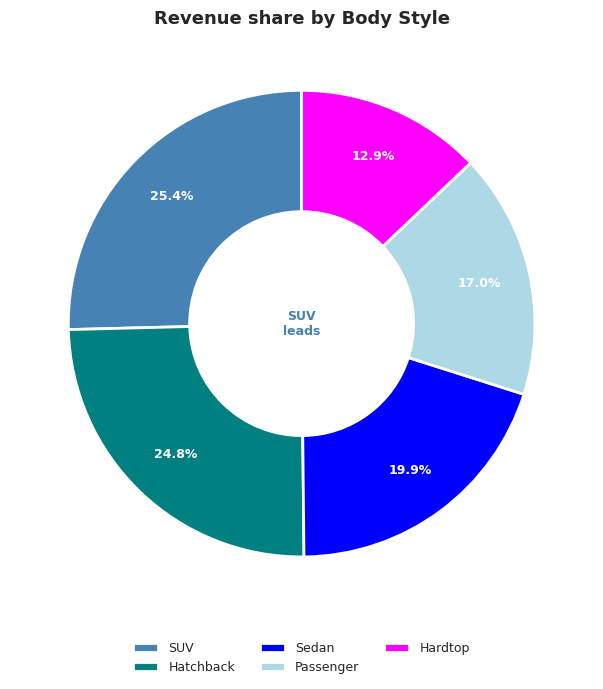

In [129]:
# Fig 2 -- Body style revenue (donut)
fig, ax = plt.subplots(figsize=(7, 7))
donut_colors = ['steelblue', 'teal', 'blue', 'lightblue', 'magenta']
wedges, _, autotexts = ax.pie(
    body_rev.values, labels=None, autopct='%1.1f%%',
    colors=donut_colors, startangle=90,
    wedgeprops=dict(width=0.52, edgecolor='white', linewidth=2),
    pctdistance=0.78,
)
for at in autotexts:
    at.set_fontsize(9); at.set_color('white'); at.set_fontweight('bold')
ax.legend(wedges, body_rev.index, loc='lower center',
          bbox_to_anchor=(0.5, -0.12), ncol=3, fontsize=9, frameon=False)
ax.add_patch(plt.Circle((0,0), 0.48, fc='white'))
ax.text(0, 0, f'{body_rev.idxmax()}\nleads', ha='center', va='center',
        fontsize=9, fontweight='bold', color='steelblue')
ax.set_title('Revenue share by Body Style', fontweight='bold', fontsize=13)
plt.tight_layout(); 
plt.show()

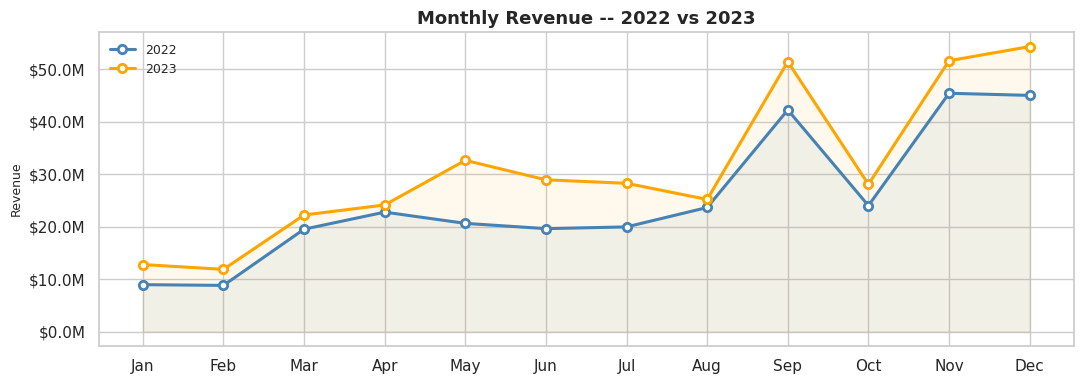

In [130]:
# Fig 3 -- Monthly revenue trend (YoY)
fig, ax = plt.subplots(figsize=(11, 4))
yr_colors = {2022: 'steelblue', 2023: 'orange'}
for yr, row in monthly_yoy.iterrows():
    col  = yr_colors.get(yr, 'lightgray')
    vals = row.values / 1e6
    ax.plot(MONTH_ORDER, vals, marker='o', linewidth=2.2, markersize=6,
            label=str(yr), color=col,
            markerfacecolor='white', markeredgewidth=2, markeredgecolor=col)
    ax.fill_between(MONTH_ORDER, vals, alpha=0.07, color=col)
ax.set_xticks(range(12)); ax.set_xticklabels(MONTH_ORDER)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:.1f}M'))
ax.set_title('Monthly Revenue -- 2022 vs 2023', fontweight='bold', fontsize=13)
ax.set_ylabel('Revenue', fontsize=9)
ax.legend(fontsize=9, frameon=False)
plt.tight_layout(); 
plt.show()

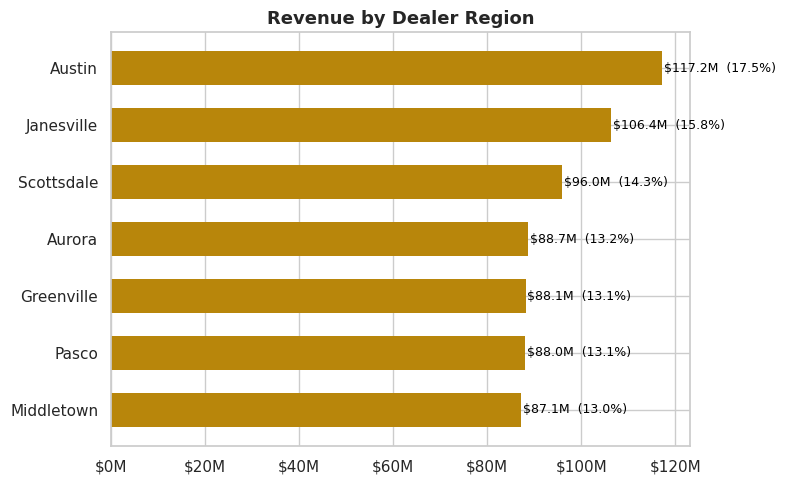

In [131]:
# Chart 4 -- Revenue by dealer region
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(region_rev.index, region_rev.values / 1e6,
               color='darkgoldenrod', edgecolor='none', height=0.6)
ax.invert_yaxis()
for bar, val in zip(bars, region_rev.values):
    ax.text(val/1e6 + 0.4, bar.get_y() + bar.get_height()/2,
            f'${val/1e6:.1f}M  ({val/total_rev:.1%})', va='center', fontsize=9, color='black')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:.0f}M'))
ax.set_title('Revenue by Dealer Region', fontweight='bold', fontsize=13)
plt.tight_layout(); plt.show()

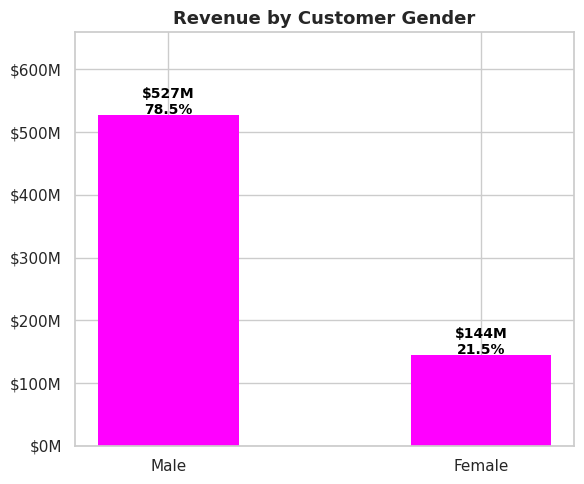

In [132]:
# Chart 5 -- Revenue by gender
fig, ax = plt.subplots(figsize=(6, 5))
bars = ax.bar(gender_rev.index, gender_rev.values / 1e6,
              color='magenta', edgecolor='none', width=0.45)
for bar, val in zip(bars, gender_rev.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            f'${val/1e6:.0f}M\n{val/total_rev:.1%}',
            ha='center', fontsize=10, fontweight='bold', color='black')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:.0f}M'))
ax.set_ylim(0, gender_rev.max()/1e6 * 1.25)
ax.set_title('Revenue by Customer Gender', fontweight='bold', fontsize=13)
plt.tight_layout(); plt.show()

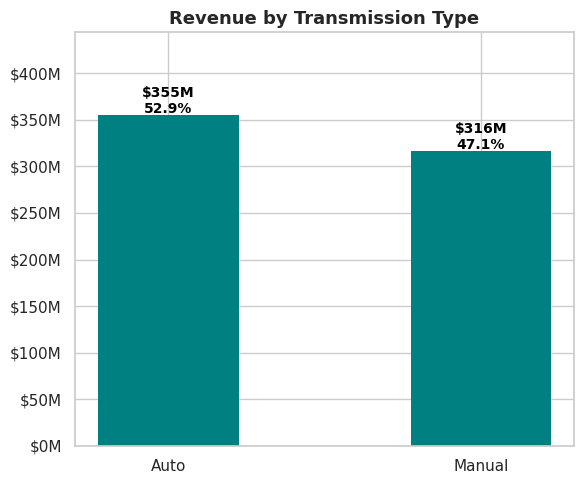

In [133]:
# Chart 6 -- Transmission split
fig, ax = plt.subplots(figsize=(6, 5))
bars = ax.bar(trans_rev.index, trans_rev.values / 1e6,
              color='teal', edgecolor='none', width=0.45)
for bar, val in zip(bars, trans_rev.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            f'${val/1e6:.0f}M\n{val/total_rev:.1%}',
            ha='center', fontsize=10, fontweight='bold', color='black')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:.0f}M'))
ax.set_ylim(0, trans_rev.max()/1e6 * 1.25)
ax.set_title('Revenue by Transmission Type', fontweight='bold', fontsize=13)
plt.tight_layout(); plt.show()

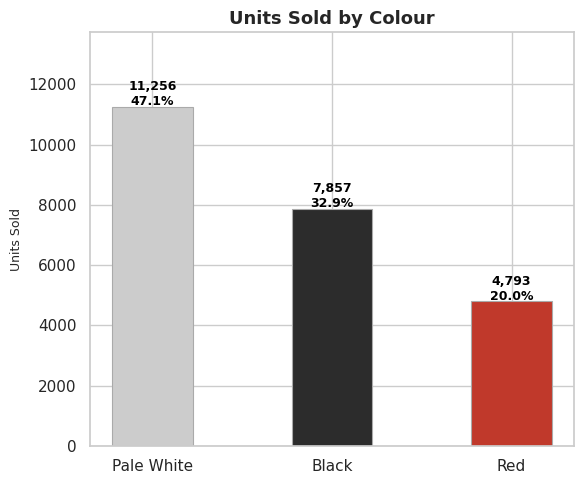

In [134]:
# Chart 7 -- Color popularity
# Using the actual car colours as bar fills makes the chart immediately readable.
fig, ax = plt.subplots(figsize=(6, 5))
actual_colors = {'Black': '#2C2C2C', 'Pale White': '#CCCCCC', 'Red': '#C0392B'}
c_c = [actual_colors[c] for c in color_units.index]
bars = ax.bar(color_units.index, color_units.values,
              color=c_c, edgecolor='#AAAAAA', linewidth=0.8, width=0.45)
for bar, val in zip(bars, color_units.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 60,
            f'{val:,}\n{val/total_units:.1%}',
            ha='center', fontsize=9, fontweight='bold', color='black')
ax.set_ylabel('Units Sold', fontsize=9)
ax.set_ylim(0, color_units.max() * 1.22)
ax.set_title('Units Sold by Colour', fontweight='bold', fontsize=13)
plt.tight_layout(); plt.show()

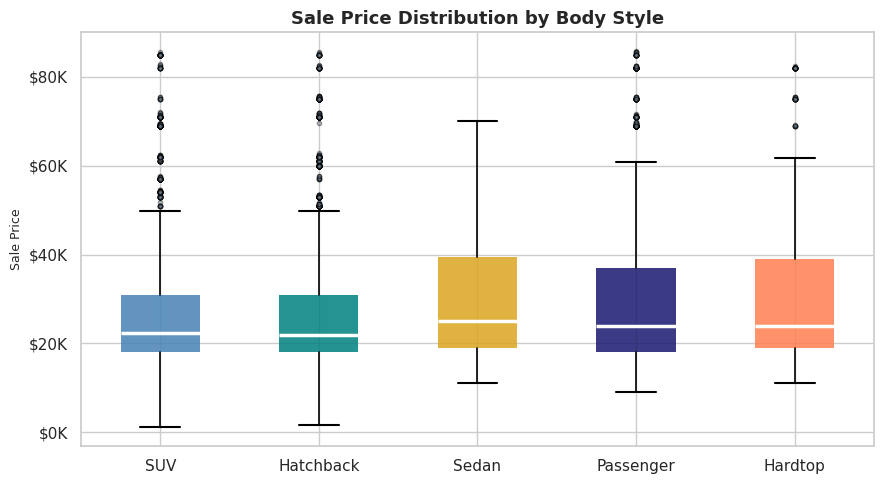

In [135]:
# Chart 8 -- Price distribution by body style (boxplot)
fig, ax = plt.subplots(figsize=(9, 5))
body_order = body_rev.index.tolist()
body_data  = [df[df['Body Style'] == b]['Price'].values for b in body_order]
bp = ax.boxplot(
    body_data, labels=body_order, patch_artist=True,
    medianprops=dict(color='white', linewidth=2.5),
    flierprops=dict(marker='o', markerfacecolor='slategray', markersize=3, alpha=0.4, linewidth=0),
    whiskerprops=dict(linewidth=1.2, color='black'),
    capprops=dict(linewidth=1.5, color='black'),
    boxprops=dict(linewidth=0),
)
for patch, col in zip(bp['boxes'], ['steelblue', 'teal', 'goldenrod', 'midnightblue', 'coral']):
    patch.set_facecolor(col); patch.set_alpha(0.85)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1000:.0f}K'))
ax.set_ylabel('Sale Price', fontsize=9)
ax.set_title('Sale Price Distribution by Body Style', fontweight='bold', fontsize=13)
plt.tight_layout(); plt.show()

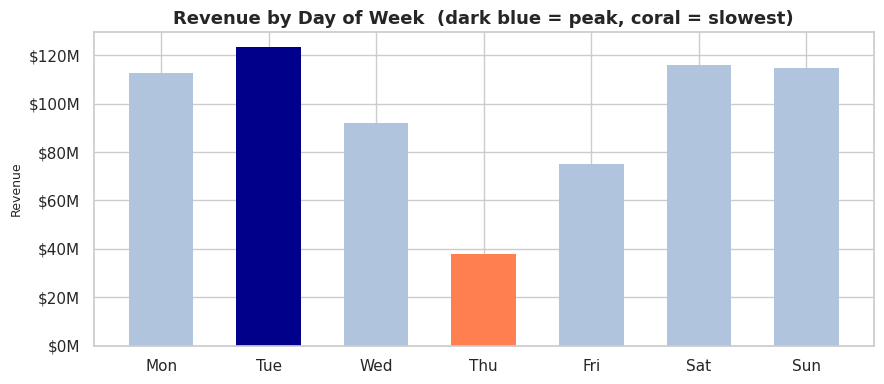

In [136]:
# Chart 9 -- Revenue by day of week
fig, ax = plt.subplots(figsize=(9, 4))
dow_labels = [d[:3] for d in DOW_ORDER]
dow_c = ['darkblue' if v == dow_rev.max() else
         'coral'   if v == dow_rev.min() else 'lightsteelblue'
         for v in dow_rev.values]
ax.bar(dow_labels, dow_rev.values / 1e6, color=dow_c, edgecolor='none', width=0.6)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:.0f}M'))
ax.set_title('Revenue by Day of Week  (dark blue = peak, coral = slowest)',
             fontweight='bold', fontsize=13)
ax.set_ylabel('Revenue', fontsize=9)
plt.tight_layout(); plt.show()

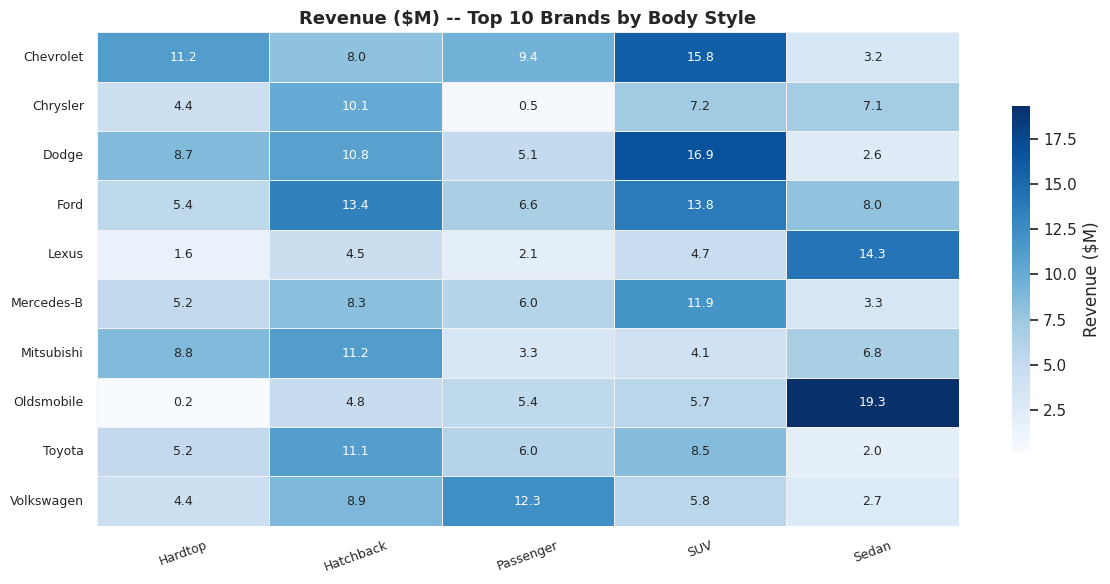

In [137]:
# Chart 10 -- Brand x Body Style revenue heatmap
fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(
    heat / 1e6, ax=ax,
    cmap='Blues', annot=True, fmt='.1f',
    linewidths=0.5, linecolor='#F0F0F0',
    cbar_kws={'label': 'Revenue ($M)', 'shrink': 0.7},
    annot_kws={'size': 9},
)
ax.tick_params(axis='x', rotation=20, labelsize=9)
ax.tick_params(axis='y', rotation=0,  labelsize=9)
ax.set_title('Revenue ($M) -- Top 10 Brands by Body Style',
             fontweight='bold', fontsize=13)
ax.set_xlabel(''); ax.set_ylabel('')
plt.tight_layout(); plt.show()

---
## Summary

In [138]:
monthly_rev = df.groupby('Month Name')['Price'].sum().reindex(MONTH_ORDER)

kpis = {
    'Total Revenue'          : f'${total_rev/1e6:.2f}M',
    'Total Units Sold'       : f'{total_units:,}',
    'Avg Sale Price'         : f'${avg_price:,.0f}',
    'Median Sale Price'      : f'${df["Price"].median():,.0f}',
    'Top Brand'              : f'{company_rev.idxmax()}  (${company_rev.max()/1e6:.2f}M)',
    'Top Dealer Region'      : f'{region_rev.idxmax()}  ({region_rev.max()/total_rev:.1%} of total)',
    'Top Body Style'         : f'{body_rev.idxmax()}  (${body_rev.max()/1e6:.2f}M)',
    'Most Popular Colour'    : f'{color_units.idxmax()}  ({color_units.max()/total_units:.1%} of units)',
    'Male Revenue Share'     : f'{gender_rev.get("Male",0)/total_rev:.1%}',
    'Female Revenue Share'   : f'{gender_rev.get("Female",0)/total_rev:.1%}',
    'Auto Transmission Share': f'{trans_rev.get("Auto",0)/total_rev:.1%}',
    'Best Month'             : f'{monthly_rev.idxmax()}  (${monthly_rev.max()/1e6:.2f}M)',
}

print('=' * 62)
print('      CAR SALES -- KEY PERFORMANCE METRICS')
print('=' * 62)
for k, v in kpis.items():
    print(f'  {k:<30s}  {v}')
print('=' * 62)

      CAR SALES -- KEY PERFORMANCE METRICS
  Total Revenue                   $671.53M
  Total Units Sold                23,906
  Avg Sale Price                  $28,090
  Median Sale Price               $23,000
  Top Brand                       Chevrolet  ($47.66M)
  Top Dealer Region               Austin  (17.5% of total)
  Top Body Style                  SUV  ($170.62M)
  Most Popular Colour             Pale White  (47.1% of units)
  Male Revenue Share              78.5%
  Female Revenue Share            21.5%
  Auto Transmission Share         52.9%
  Best Month                      Dec  ($99.27M)


---
## Key takeaways

**What the data says:**

- **Chevrolet, Dodge and Ford sit almost neck and neck** at the top of the revenue table. No single brand dominates, which gives dealers meaningful room to manoeuvre on margin and inventory mix.

- **Austin is in a different league.** At $117M it generates 17.4% of all revenue despite being one of seven equal-sized regions. That gap deserves a proper root-cause investigation -- is it population density, dealership quality, product mix, or something else?

- **December is the obvious peak** in both years, but the YoY chart reveals that 2023 saw stronger mid-year performance in May through September. If that trend holds, the planning window for Q3 staffing and inventory becomes more important.

- **Pale White accounts for nearly half of all units sold.** With only three colours in the catalogue, this concentration is striking. Black and Red together cover the other 53%, roughly split between the two.

- **The gender gap is the biggest commercial opportunity.** Male buyers drive 78.5% of revenue while female buyers account for just 21.5%. Whether that reflects product mix, marketing, or something else in the sales process, closing even a few percentage points of that gap would be material.

- **Engine type and transmission are perfectly correlated.** Double Overhead Camshaft always pairs with Auto; Overhead Camshaft always pairs with Manual. They are effectively one variable masquerading as two.
